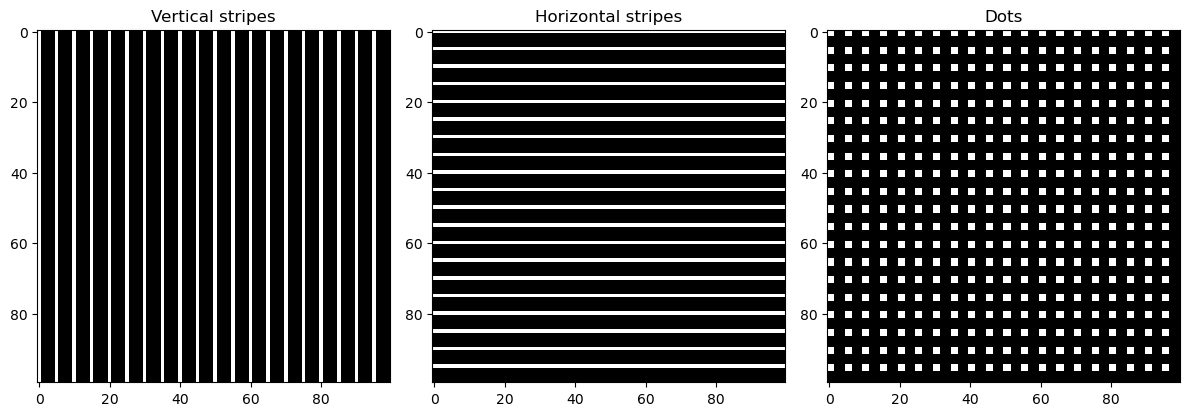

In [8]:
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

def create_striped_image(width, height, spacing, thickness=1, orientation='vertical'):
    # create an image with stripes - vertical and horizontal, with variable thickness
    img = Image.new("RGB", (width, height), "black")
    draw = ImageDraw.Draw(img)
    
    if orientation == 'vertical':
        for x in range(0, width, spacing):
            draw.line([(x, 0), (x, height)], fill="white", width=thickness)
    elif orientation == 'horizontal':
        for y in range(0, height, spacing):
            draw.line([(0, y), (width, y)], fill="white", width=thickness)
    
    return img

def create_dot_image(width, height, spacing, dot_size=1):
    # create an image with regularly spaced square dots
    img = Image.new("RGB", (width, height), "black")
    draw = ImageDraw.Draw(img)
    
    for x in range(0, width, spacing):
        for y in range(0, height, spacing):
            draw.rectangle([x, y, x + dot_size, y + dot_size], fill="white")
    
    return img

# test all images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

vertical = create_striped_image(100, 100, spacing=5, thickness=1, orientation='vertical')
horizontal = create_striped_image(100, 100, spacing=5, thickness=1, orientation='horizontal')
dots = create_dot_image(100, 100, spacing=5, dot_size=1)

axes[0].imshow(vertical)
axes[0].set_title('Vertical stripes')
axes[1].imshow(horizontal)
axes[1].set_title('Horizontal stripes')
axes[2].imshow(dots)
axes[2].set_title('Dots')

plt.tight_layout()
plt.show()

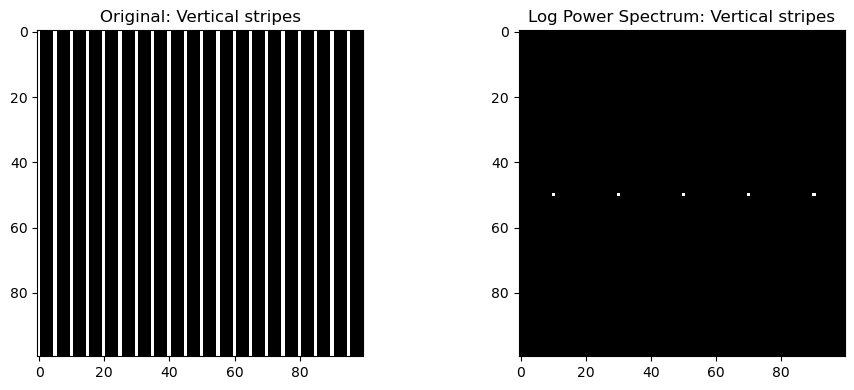

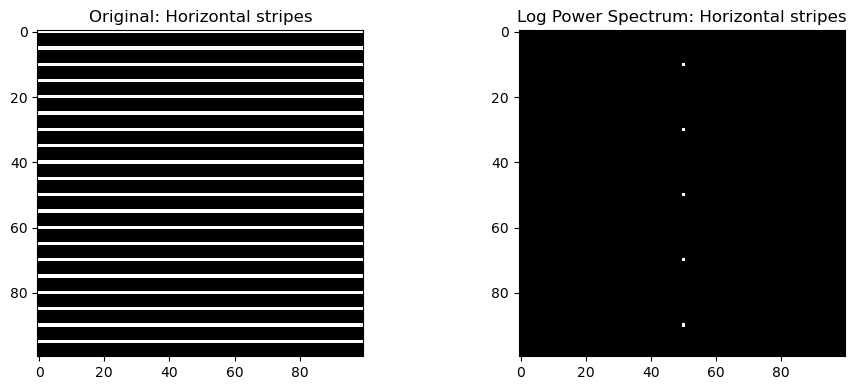

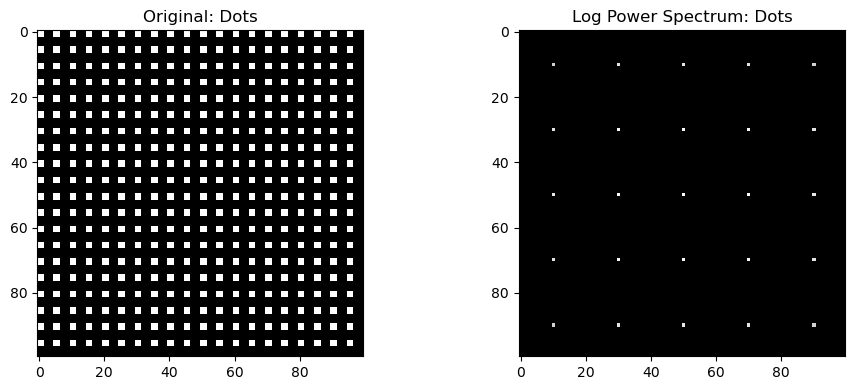

In [9]:
def compute_fft(img):
    # compute 2D FFT and power spectrum of an image
    # convert to grayscale numpy array
    img_gray = np.array(img.convert("L"))
    
    # compute 2D FFT
    fft_result = np.fft.fft2(img_gray)
    
    # shift zero frequency to centre for better visualisation
    fft_shifted = np.fft.fftshift(fft_result)
    
    # power spectrum and log power spectrum
    power_spectrum = np.abs(fft_shifted) ** 2.0
    log_power_spectrum = np.log(1.0 + power_spectrum)
    
    return fft_result, power_spectrum, log_power_spectrum

def plot_fft(img, title):
    # plot original image alongside its log power spectrum
    fft_result, power_spectrum, log_power_spectrum = compute_fft(img)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Original: {title}')
    axes[1].imshow(log_power_spectrum, cmap='gray')
    axes[1].set_title(f'Log Power Spectrum: {title}')
    plt.tight_layout()
    plt.show()

# plot power spectra for all three images
plot_fft(vertical, 'Vertical stripes')
plot_fft(horizontal, 'Horizontal stripes')
plot_fft(dots, 'Dots')

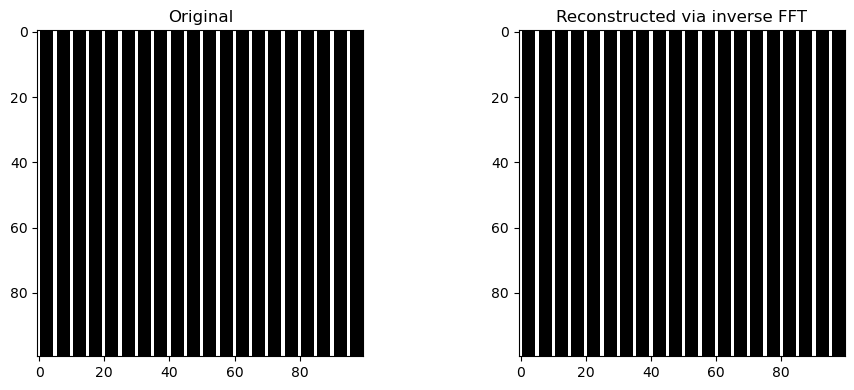

In [10]:
def compute_ifft(fft_result):
    # inverse FFT to reconstruct image
    ifft_result = np.fft.ifft2(fft_result)
    return np.abs(ifft_result)

# verify reconstruction on vertical stripes
fft_result, _, _ = compute_fft(vertical)
reconstructed = compute_ifft(fft_result)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(vertical)
axes[0].set_title('Original')
axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title('Reconstructed via inverse FFT')
plt.tight_layout()
plt.show()

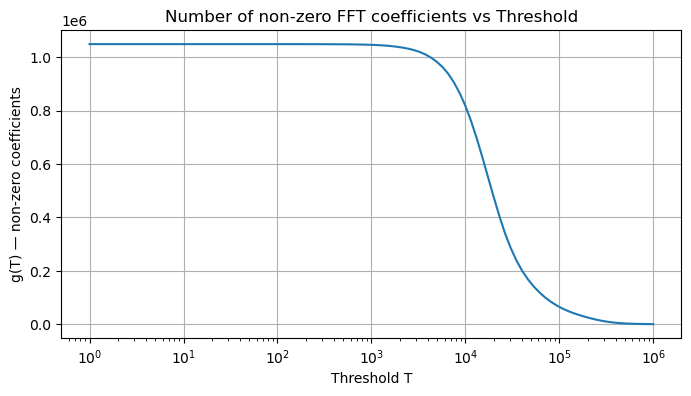

In [11]:
from scipy import optimize

def threshold_fft(fft_result, T):
    # set FFT coefficients below threshold T to zero
    fft_threshold = fft_result.copy()
    fft_threshold[np.abs(fft_result) < T] = 0
    return fft_threshold

def calc_g(fft_result, T):
    # count non-zero coefficients after thresholding
    fft_threshold = threshold_fft(fft_result, T)
    g = np.count_nonzero(fft_threshold)
    return g, fft_threshold

# load owl image
owl = Image.open("owl.png").convert("L")
owl_array = np.array(owl)
M, N = owl_array.shape

# compute FFT
owl_fft = np.fft.fft2(owl_array)

# calculate g(T) for a range of T values
T_values = np.logspace(0, 6, 100)
g_values = [calc_g(owl_fft, T)[0] for T in T_values]

# plot g(T)
plt.figure(figsize=(8, 4))
plt.plot(T_values, g_values)
plt.xscale('log')
plt.xlabel('Threshold T')
plt.ylabel('g(T) — non-zero coefficients')
plt.title('Number of non-zero FFT coefficients vs Threshold')
plt.grid(True)
plt.show()

Target r=0.1000, Actual r=0.1000, T=68355.19
Target r=0.0100, Actual r=0.0100, T=314056.09
Target r=0.0050, Actual r=0.0050, T=418061.08


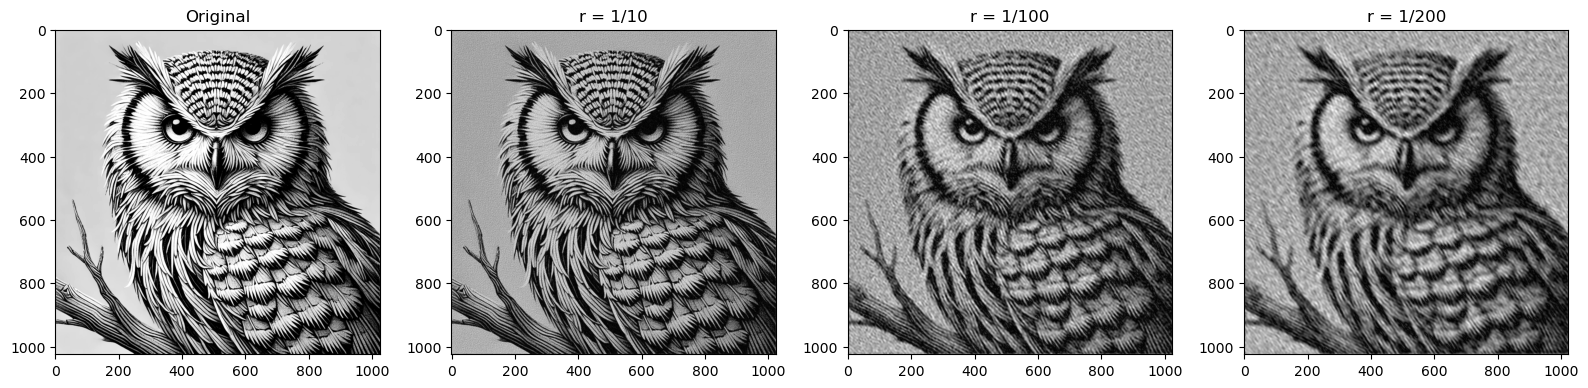

In [7]:
def compress_image(fft_result, r, M, N):
    # compress image to a given ratio r = g(T)/(M*N)
    # find threshold T that gives compression ratio r
    h = lambda T: calc_g(fft_result, T)[0] - r * M * N
    T = optimize.bisect(h, 1, 1e6)
    
    # apply threshold
    _, fft_threshold = calc_g(fft_result, T)
    
    # reconstruct image
    compressed = np.abs(np.fft.ifft2(fft_threshold))
    
    # calculate actual compression ratio
    actual_r = calc_g(fft_result, T)[0] / (M * N)
    print(f"Target r={r:.4f}, Actual r={actual_r:.4f}, T={T:.2f}")
    
    return compressed

# plot original vs compressed at different ratios
ratios = [1/10, 1/100, 1/200]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(owl_array, cmap='gray')
axes[0].set_title('Original')

for i, r in enumerate(ratios):
    compressed = compress_image(owl_fft, r, M, N)
    axes[i+1].imshow(compressed, cmap='gray')
    axes[i+1].set_title(f'r = 1/{int(1/r)}')

plt.savefig('gT_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('compression_results.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()